# Explore the catalog using interactive plotly graphs

In [310]:
import json
import numpy as np
import pandas as pd

import sys, os
from io import StringIO

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR, DOCS_DIR

file_path = MAIN_CATALOG


## Some helper functions

In [311]:
# === Load JSON ===
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

def extract_triplet_array(data, key):
    """Return an (N,3) float array for the given triplet key, robust to None/NaN."""
    rows = []
    for entry in data:
        val = entry.get(key, None)
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 3:
            try:
                rows.append([float(val[0]), float(val[1]), float(val[2])])
            except Exception:
                rows.append([np.nan, np.nan, np.nan])
        elif isinstance(val, (int, float)):
            # Scalar provided, treat as central value with unknown errors
            rows.append([np.nan, float(val), np.nan])
        else:
            rows.append([np.nan, np.nan, np.nan])
    return np.array(rows, dtype=float)

# ==  Function to easily extract some of the cols ==    
def extract_array(data, key):
    """Extracts a given key from each system and returns a list."""
    try:
        values = [entry.get(key, None) for entry in data]
        return values  # Return list, not np.array - let to_triplet_array handle conversion
    except Exception as e:
        print(f"Error extracting {key}: {e}")
        return None

def to_triplet_array(arr):
    """
    Convert array-like of triplets to (N,3) float array.
    Invalid entries become [nan, nan, nan].
    """
    if arr is None:
        return np.array([])
    
    out = []
    for row in arr:
        if isinstance(row, (list, tuple, np.ndarray)) and len(row) == 3:
            out.append(row)
        else:
            out.append([np.nan, np.nan, np.nan])
    return np.array(out, dtype=float)



def read_json_file_topd(file_path, as_dataframe=True):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)

        # If JSON is a dict of systems → convert to list
        if isinstance(data, dict):
            data = list(data.values())

        if as_dataframe:
            return pd.DataFrame(data)

        return data

    except Exception as e:
        print(f"Error reading file: {e}")
        return None



## Inspect catalog

In [312]:
# Read data
pd_catalog_data = read_json_file_topd(MAIN_CATALOG)

# Print the keys
print(pd_catalog_data.keys())

# Data looks like:
display(pd_catalog_data[pd_catalog_data["system_class"] == "Contact binary"])


Index(['System Name', 'Type1', 'Type2', 'Detection Method', 'Reference',
       'Notes', 'RA', 'Dec', 'Period', 'Eccentricity', 'M1', 'M1_sin3i', 'M2',
       'M2_sin3i', 'q', 'Mass Function', 'source_file', 'evol_type_1',
       'evol_type_2', 'obs_type_1', 'obs_type_2', 'system_class', 'Simbad'],
      dtype='object')


,System Name,Type1,Type2,Detection Method,Reference,Notes,RA,Dec,Period,Eccentricity,...,M2_sin3i,q,Mass Function,source_file,evol_type_1,evol_type_2,obs_type_1,obs_type_2,system_class,Simbad
148,LSS 3074,"O6-7:(f):, Contact","O4 f +, Contact","[RV, EB]",2017A&A...601A.133R,Gaia DR3 5868409430865830912,"[0.0097, 201.74924, 0.0097]","[0.0118, -62.03038, 0.0118]","[0.0006, 2.1852, 0.0006]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.86, 0.04]","[None, None, None]",contact1.h5,MS,MS,O6-7:(f):,O4 f +,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
149,MY Cam,"O4.5-6V, Contact","O6V, Contact","[RV, EB]",2014A&A...572A.110,Gaia DR3 469715181320008960,"[0.0236, 59.82622, 0.0236]","[0.0207, 57.23716, 0.0207]","[0.0, 1.17545, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.84, 0.04]","[None, None, None]",contact1.h5,MS,MS,O4.5-6V,O6V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
150,OGLE SMC-SC10 108086,"O9V, Contact","O9.5-B0V, Contact","[RV, EB]",2005MNRAS.357..304H,"Gaia DR3 4690510870334496896, SMC","[0.0242, 16.37751, 0.0242]","[0.0219, -72.0227, 0.0219]","[None, 0.8831, None]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.06, 0.85, 0.06]","[None, None, None]",contact1.h5,MS,MS,O9V,O9.5-B0V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
151,TU Mus,"O7V, Contact","O8V, Contact","[RV, EB, IUE]",2008ApJ...681..554P,"Gaia DR3 5237207155697930496, HD 100213","[0.0188, 172.79544, 0.0188]","[0.0195, -65.74225, 0.0195]","[0.0, 1.38728, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.009, 0.623, 0.009]","[None, None, None]",contact1.h5,MS,MS,O7V,O8V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
152,V382 Cyg,"O6.5V((f)), Contact","O6V((f)), Contact","[RV, EB]",2017A&A...607A..82M,"Gaia DR3 2057530097777247744, HD 228854","[0.0183, 304.69673, 0.0183]","[0.024, 36.34055, 0.024]","[1e-05, 1.88555, 1e-05]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.005, 0.727, 0.005]","[None, None, None]",contact1.h5,MS,MS,O6.5V((f)),O6V((f)),Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
153,VFTS 352,"O4.5 V(n)((fc))z, Contact","O5.5 V(n)((fc))z, Contact","[RV, EB]",2015ApJ...812..102A,"Gaia DR3 4657678216202797440, LMC","[0.017, 84.61859, 0.017]","[0.0195, -69.18864, 0.0195]","[0.0, 1.12415, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.1, 0.99, 0.1]","[None, None, None]",contact1.h5,MS,MS,O4.5 V(n)((fc))z,O5.5 V(n)((fc))z,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
154,CT Tau,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,"Gaia DR3 3430795519289951744,HD 249751","[0.021, 89.70881, 0.021]","[0.0182, 27.0783, 0.0182]","[0.0, 0.66683, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.983, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
155,GU Mon,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,Gaia DR3 3125506151511957120,"[0.0172, 101.19525, 0.0172]","[0.0172, 0.22175, 0.0172]","[0.0, 0.89665, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.976, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
156,SV Cen,"B, Contact?","B, Contact?","[RV, EB]",1992AJ....103..573R,"Gaia DR3 5335388664983921024, HD 102552,Pdot s...","[0.0235, 176.98836, 0.0235]","[0.0222, -60.56604, 0.0222]","[0.001, 1.658, 0.001]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.002, 0.71, 0.002]","[None, None, None]",contact1.h5,MS,MS,B,B,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
157,V606 Cen,"B0.5V, Contact","B2V, Contact","[RV, EB]","1999A&A...345..531L,2022ApJ...924...30L","Gaia DR3 5869546428991037312, HD 115937; tripl...","[0.0092, 200.40113, 0.0092]","[0.011, -60.52077, 0.011]","[0.0, 1.4951, 0.0]","[0.07, 0.33, 0.07]",...,"[None, None, None]","[0.0007, 0.5484, 0.0007]","[None, None, None]",contact1.h5,MS,MS,B0.5V,B2V,Contact binary,

In [313]:
# Example: Extract M1 values with the helper function
M1 = to_triplet_array(pd_catalog_data['M1'] )

# Extract median M1 values
print(M1[:,1])  

# M1 values with min and max errors
print(pd_catalog_data['M1'][:]) 

[ nan  nan  nan ... 1.6  1.65 1.57]
0       [None, None, None]
1       [None, None, None]
2       [None, None, None]
3       [None, None, None]
4       [None, None, None]
               ...        
4608    [0.07, 1.69, 0.07]
4609     [0.04, 1.4, 0.04]
4610     [0.08, 1.6, 0.08]
4611    [0.06, 1.65, 0.06]
4612    [0.05, 1.57, 0.05]
Name: M1, Length: 4613, dtype: object


## Interactive Plotting with Plotly 


First do a little bit of data prep and color/symbol map definition

In [314]:
# Read data
data = read_json_file(str(file_path))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)

# Extract triplet columns once for efficiency/consistency
period_arr = extract_triplet_array(data, 'Period')
ecc_arr = extract_triplet_array(data, 'Eccentricity')
m1_arr = extract_triplet_array(data, 'M1')
m2_arr = extract_triplet_array(data, 'M2')

# Build a single DataFrame with central values and errors
df = pd.DataFrame({
    'Period': period_arr[:, 1],
    'Period_err_minus': period_arr[:, 0],
    'Period_err_plus': period_arr[:, 2],
    'Eccentricity': ecc_arr[:, 1],
    'Eccentricity_err_minus': ecc_arr[:, 0],
    'Eccentricity_err_plus': ecc_arr[:, 2],
    'M1': m1_arr[:, 1],
    'M1_err_minus': m1_arr[:, 0],
    'M1_err_plus': m1_arr[:, 2],
    'M2': m2_arr[:, 1],
    'M2_err_minus': m2_arr[:, 0],
    'M2_err_plus': m2_arr[:, 2],
    'System Name': [entry.get('System Name', '') for entry in data],
    'obs_type_1': [entry.get('obs_type_1', '') for entry in data],
    'obs_type_2': [entry.get('obs_type_2', '') for entry in data],
    'evol_type_1': [entry.get('evol_type_1', '') for entry in data],
    'evol_type_2': [entry.get('evol_type_2', '') for entry in data],
    'system_class': [entry.get('system_class', 'None') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})

# # Hand-picked colors for each class (hex strings). Adjust as you like.
# COLORMAP = {
#     'contact binaries': '#f49856',  # light olive
#     'Algols': '#6d2c14',            # maroon
#     'Hot subdwarfs': '#6d4aa0', # UV purple 
#     'Stripped stars': '#408c63', # muted green
#     'Wolf-Rayet': '#52b4e5',     # blue 
#     'Post AGB stars': '#ea4d4d', # coral/red 
#     # 
#     'Black Holes': '#565656',   # orange
#     'Blue Straggler Stars': '#f4d25a',
#     'Neutron star': '#9bd24e',   # lime green
#     'Barium stars': '#af52a6',    # purple  
#     'White Dwarf': '#e6cfd9',    # purple 
#     'Unclassified': '#cbd24f'
# }

# Hand-picked colors and symbols for each class (hex strings). Adjust as you like.
# Combined color and symbol map for each system class
STYLE_MAP = {
    # Binaries w. non-degenerate components
    'Contact binary': {'color': '#f49856', 'symbol': 'circle'},           # orange
    'Algol': {'color': '#6d2c14', 'symbol': 'diamond'},                   # maroon
    'Hot subdwarf': {'color': '#37a8a8', 'symbol': 'square'},             # UV purple
    'Stripped star': {'color': '#3a8ea3', 'symbol': 'x'},  # muted green
    'WR binary': {'color': '#52b4e5', 'symbol': 'triangle-up'},       # blue
    'post AGB': {'color': '#ea4d4d', 'symbol': 'cross'},           # coral/red
    
    # Binaries containing white dwarfs
    'EL CVn': {'color': '#8864ba', 'symbol': 'star'},         # orange
    'Blue straggler binary': {'color': '#6a65b2', 'symbol': 'hourglass'}, # yellow
    'Chemically peculiar star': {'color': '#af52a6', 'symbol': 'pentagon'}, # gray #FF6692 gumball
    'Astrometric WD + MS': {'color': '#e6cfd9', 'symbol': 'circle'},                  # light purple
    'Spectroscopic WD + MS': {'color': '#e6cfd9', 'symbol': 'cross-dot'},                  # light purple
    
    # Binaries containing neutron stars or black holes
    'Pulsar binary': {'color': '#9bd24e', 'symbol': 'diamond'},           # lime green
    'X-ray binary': {'color': '#1abc9c', 'symbol': 'square'},             # muted green
    'Spectroscopic compact object': {'color': '#cbd24f', 'symbol': 'x'},  # yellow green
    'Astrometric compact object': {'color': '#408c63', 'symbol': 'triangle-up'}  # muted green
}

# Extract color and symbol maps for backward compatibility
COLORMAP = {k: v['color'] for k, v in STYLE_MAP.items()}
SYMBOLMAP = {k: v['symbol'] for k, v in STYLE_MAP.items()}


In [315]:
# display(df['obs_type_1'][df['obs_type_1'].notna()])  # Display non-empty obs_type_1 values
# Look at specific system
display(df[ df['System Name'] == 'EXO 1722-363'])

,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,M1_err_minus,M1_err_plus,M2,M2_err_minus,M2_err_plus,System Name,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
3951,9.7403,0.0004,0.0004,0.19,1.0,1.0,18.0,2.0,2.0,1.91,0.45,0.45,EXO 1722-363,B0-1Ia,NS?,MS,NS,high-mass XRB,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


#### Plotly plotting function

In [316]:
# All of these are lucky okay :)
# display(df[(df['M1']- df['M1_err_minus']) <0])
# display(df[(df['M2']- df['M2_err_minus']) <0])
# display(df[(df['Period']- df['Period_err_minus']) <0])
# But there are 243 instances where eccentricity minus error is <0! 
display(df['System Name'][(df['Eccentricity']- df['Eccentricity_err_minus']) <0])

display(df['System Name'][(df['Eccentricity']+ df['Eccentricity_err_plus']) >1  ])

306      Gaia DR3 22172240385273088
330     Gaia DR3 193686502314902400
331     Gaia DR3 196552271996570368
334     Gaia DR3 199153274128487936
336     Gaia DR3 205091457254043904
                   ...             
3680                 TYC 9104-773-1
3681                  TYC 8019-58-1
3951                   EXO 1722-363
3966                IGR J18027-2016
4000                     4U 1909+07
Name: System Name, Length: 245, dtype: object

1694    Gaia DR3 2933937175458047744
3951                    EXO 1722-363
3966                 IGR J18027-2016
Name: System Name, dtype: object

In [317]:
def make_scatter(df, x, y, out_pdf, out_html=None, x_log=False, y_log=False, x_title=None, y_title=None,
                export_legend_to_pdf=True, export_width=700, export_height=450, export_scale=2, 
                 tick_size = 15,label_size = 25):

    # Drop any rows where either x or y is NaN
    sub = df.dropna(subset=[x, y]).copy()

    # Set  error bars and Fill missing error columns with zero
    sub[f"{x}_err_plus"] = sub[f"{x}_err_plus"].fillna(0)
    sub[f"{x}_err_minus"] = sub[f"{x}_err_minus"].fillna(0)
    sub[f"{y}_err_plus"] = sub[f"{y}_err_plus"].fillna(0)
    sub[f"{y}_err_minus"] = sub[f"{y}_err_minus"].fillna(0)

    # Check that errors don't drop below zero
    for param in [x, y]:
        # wherever the value minus the minus error is <0, set the minus error to the value itself
        # I.e, limit the error bar to not go below zero
        mask_min = sub[param] - sub[f"{param}_err_minus"] < 0
        sub.loc[mask_min, f"{param}_err_minus"] = sub.loc[mask_min, param] 
        print(f"Corrected {mask_min.sum()} negative {param} minus errors.")
        # Also ensure that Eccentricities do not exceed 1
        if param == 'Eccentricity': 
            mask_plus = sub[param] + sub[f"{param}_err_plus"] > 1
            sub.loc[mask_plus, f"{param}_err_plus"] = 1 - sub.loc[mask_plus, param]
            print(f"Corrected {mask_plus.sum()} eccentricity plus errors exceeding 1.")

    print(df[['Eccentricity','Eccentricity_err_plus']][df['System Name']== 'EXO 1722-363'])

    # Replace obs and evol_ type 'None' with 'Unknown' (for hover info)
    sub['obs_type_1'] = sub['obs_type_1'].fillna('Unknown')
    sub['obs_type_2'] = sub['obs_type_2'].fillna('Unknown')
    sub['evol_type_1'] = sub['evol_type_1'].fillna('Unknown')
    sub['evol_type_2'] = sub['evol_type_2'].fillna('Unknown')

    # Create figure with traces per system class
    fig = px.scatter(sub,x=x,y=y,
        error_x=f"{x}_err_plus", error_x_minus=f"{x}_err_minus", error_y=f"{y}_err_plus", error_y_minus=f"{y}_err_minus",
        color='system_class',color_discrete_map=COLORMAP,
        symbol='system_class',symbol_map=SYMBOLMAP,
        hover_name='System Name',
        hover_data=[
            'obs_type_1', 'obs_type_2', 'evol_type_1', 'evol_type_2',
            f'{x}_err_plus', f'{x}_err_minus', 
            f'{y}_err_plus', f'{y}_err_minus'
        ],
        template='plotly_white',
        category_orders={'system_class': list(STYLE_MAP.keys())}  # set order of things in legend
    )
    fig.update_layout(
        legend_title_text='System Class',
        legend=dict(itemclick='toggle', itemdoubleclick='toggleothers'),
        legend_title=dict(font=dict(size=15)),
        legend_font=dict(size=14)
    )

    # Set the axis titles and their label sizes
    x_kwargs = dict(title_text=x_title, tickfont=dict(size=tick_size), title_font=dict(size=label_size))
    y_kwargs = dict(title_text=y_title, tickfont=dict(size=tick_size), title_font=dict(size=label_size))
    if x_log:
        x_kwargs['type'] = 'log'
    if y_log:
        y_kwargs['type'] = 'log'
    fig.update_xaxes(**x_kwargs)
    fig.update_yaxes(**y_kwargs)


    # Save the PDF and HTML
    if out_html is not None:
        out_html = Path(out_html)
        out_html.parent.mkdir(parents=True, exist_ok=True)
        fig.update_layout(font=dict(size=14))
        # Write the interactive HTML with the legend intact
        fig.write_html(str(out_html), include_plotlyjs='cdn', include_mathjax='cdn')

    if out_pdf is not None:
        out_pdf = Path(out_pdf)
        out_pdf.parent.mkdir(parents=True, exist_ok=True)
        # For static exports (PDF/PNG) we may want to hide the legend
        try:
            orig_showlegend = True
            if hasattr(fig.layout, 'showlegend') and fig.layout.showlegend is not None:
                orig_showlegend = bool(fig.layout.showlegend)
            fig.update_layout(showlegend=export_legend_to_pdf)
            # Pass width/height/scale to write_image to control PDF resolution.
            fig.write_image(str(out_pdf), width=export_width, height=export_height, scale=export_scale)
            print(f'Wrote PDF: {out_pdf} (w={export_width}, h={export_height}, scale={export_scale})')
        except Exception as e:
            print(f'Could not write PDF for {out_pdf}:', e)
        finally:
            # restore legend visibility for any further interactive use
            try:
                fig.update_layout(showlegend=orig_showlegend)
            except Exception:
                pass

    # Show the interactive plot in the notebook (optional)
    #set the size of the shown figure
    fig.update_layout(width=export_width, height=export_height)
    fig.show()


In [318]:
## Perios vs eccentricity 
make_scatter(
    df,
    x='Period', y='Eccentricity',
    out_html=None,
    out_pdf=None,
    x_log=True, y_log=False,
    x_title=r'P (days)', 
    y_title=r'e',  
    export_legend_to_pdf=False, 
    export_height=600,
    export_width=900,
    export_scale=3
)

Corrected 0 negative Period minus errors.
Corrected 245 negative Eccentricity minus errors.
Corrected 3 eccentricity plus errors exceeding 1.
      Eccentricity  Eccentricity_err_plus
3951          0.19                    1.0


In [319]:
display(df[ df['System Name'] == 'CRTS J225539.4+342138'])

,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,M1_err_minus,M1_err_plus,M2,M2_err_minus,M2_err_plus,System Name,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
4609,0.571785,3.000000e-07,3.000000e-07,NaN,NaN,NaN,1.4,0.04,0.04,0.26,0.04,0.04,CRTS J225539.4+342138,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [320]:
## Perios vs donor mass 
make_scatter(
    df,
    x='Period', y='M2',
    out_html=None,
    out_pdf=None,
    x_log=True, y_log=True,
    x_title='P (days)', 
    y_title=r'Mdonor (Msun)',
    export_legend_to_pdf=False,
    export_height=500,
    export_width=800,
    export_scale=2
)

Corrected 0 negative Period minus errors.
Corrected 0 negative M2 minus errors.
      Eccentricity  Eccentricity_err_plus
3951          0.19                    1.0


In [321]:
display(df[ df['System Name'] == 'SDSS0901-4809'])


,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,M1_err_minus,M1_err_plus,M2,M2_err_minus,M2_err_plus,System Name,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
4150,NaN,NaN,NaN,NaN,NaN,NaN,0.138,0.131,0.145,0.752,0.734,0.776,SDSS0901-4809,None,WD,None,WD,WD + MS,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [322]:
## donor (2) vs accretor (1) mass
make_scatter(
    df,
    x='M1', y='M2',
    out_html=None,
    out_pdf=None,
    x_log=True, y_log=True,
    x_title='M accretor (Msun)', 
    y_title='M donor (Msun)',
    export_legend_to_pdf=True,
    export_height=500,
    export_width=800,
    export_scale=2
)

Corrected 1 negative M1 minus errors.
Corrected 0 negative M2 minus errors.
      Eccentricity  Eccentricity_err_plus
3951          0.19                    1.0


In [ ]:
'circle', 'circle-open' 
'circle-dot'
'circle-open-dot'
'square', 
'square-open' 
'square-dot'  'square-open-dot'2'
'diamond', 'diamond-open' 
'diamond-dot' 'diamond-open-dot'3',
'cross', 'cross-open' 
'cross-dot' 'cross-open-dot',  ', 'x',
'x-open' 
'x-open-dot','5', 'triangle-up',
'triangle-up-open'  'triangle-up-dot'
'305', 'triangle-up-open-dot', 6, '6', 'triangle-down',
106,, 'triangle-down-open' 
'triangle-down-dot' 'triangle-down-open-dot',
7, '7', 'triangle-left', 'triangle-left-open',
207,  'triangle-left-dot'
'triangle-left-open-dot', 8, '8', 'triangle-right'
'108', 'triangle-right-open' 
'triangle-right-dot'
'triangle-right-open-dot', 9, '9', 'triangle-ne'
'109', 'triangle-ne-open'  'triangle-ne-dot',
309, 'triangle-ne-open-dot''10',
'triangle-se', 'triangle-se-open' 
'triangle-se-dot' 'triangle-se-open-dot''11', 'triangle-sw', 'triangle-sw-open'
'211', 'triangle-sw-dot'
'triangle-sw-open-dot''12', 'triangle-nw'
'112', 'triangle-nw-open'  'triangle-nw-dot',
312, 'triangle-nw-open-dot''13', 'pentagon',
113,, 'pentagon-open'  'pentagon-dot',
313, 'pentagon-open-dot''1, 'hexagon'
'11, 'hexagon-open' hexagon-dot'
'31, 'hexagon-open-dot' 'hexagon2'
'115', 'hexagon2-open'  'hexagon2-dot'
'315', 'hexagon2-open-dot''16', 'octagon'
'116', 'octagon-open'  'octagon-dot'
'316', 'octagon-open-dot''17', 'star',
'star-open'  'star-dot'
'star-open-dot''18', 'hexagram',
'hexagram-open'  'hexagram-dot'
'hexagram-open-dot''19', 'star-triangle-up'
'119', 'star-triangle-up-open' 
'star-triangle-up-dot'
'star-triangle-up-open-dot''20',
'star-triangle-down',
'star-triangle-down-open' 
'star-triangle-down-dot'
'star-triangle-down-open-dot''21', 'star-square',
121,, 'star-square-open' 
'star-square-dot' 'star-square-open-dot''22', 'star-diamond', 'star-diamond-open',
222,  'star-diamond-dot'
'star-diamond-open-dot''23', 'diamond-tall'
'123', 'diamond-tall-open' 
'diamond-tall-dot' 'diamond-tall-open-dot',
'diamond-wide', 'diamond-wide-open',
'diamond-wide-dot''diamond-wide-open-dot'' 'hourglass'
 'hourglass-open''26', 'bowtie',
'bowtie-open''27', 'circle-cross',
'circle-cross-open''28', 'circle-x',
'circle-x-open''29', 'square-cross',
'square-cross-open''30', 'square-x',
'square-x-open''31', 'diamond-cross',
'diamond-cross-open''32', 'diamond-x',
'diamond-x-open''33', 'cross-thin',
'cross-thin-open''3, 'x-thin',
'x-thin-open''35', 'asterisk',
'asterisk-open''36', 'hash',
'hash-open'  'hash-dot'
'hash-open-dot''37', 'y-up',
'y-up-open''38', 'y-down',
'y-down-open''39', 'y-left',
'y-left-open', , '', 'y-right',
'y-right-open', , '', 'line-ew',
'line-ew-open', , '', 'line-ns',
'line-ns-open', , '', 'line-ne',
'line-ne-open',  ', 'line-nw',
'line-nw-open', , '', 'arrow-up',
'arrow-up-open', , '', 'arrow-down',
'arrow-down-open', , '', 'arrow-left',
'arrow-left-open', , '', 'arrow-right',
'arrow-right-open', , '', 'arrow-bar-up',
'arrow-bar-up-open', '50', 'arrow-bar-down'
'150', 'arrow-bar-down-open', '51', 'arrow-bar-left',
151,, 'arrow-bar-left-open', '52',
'arrow-bar-right', 'arrow-bar-right-open',
'53', 'arrow', 'arrow-open',5,
'arrow-wide', 'arrow-wide-open']

In [ ]:
# === Interactive Plotting with Plotly ===
def plotly_vars(x_key, y_key, df, logx=False, logy=False, color_by="system_class", color_map=None):
    """
    Create interactive plotly scatter plot with error bars.
    
    Parameters:
        x_key, y_key: str
            Column names for x and y axes (e.g., 'Period', 'M1', 'Eccentricity')
        df: pandas DataFrame
            DataFrame with the catalog data (e.g., pd_catalog_data)
        logx, logy: bool
            Whether to use logarithmic axes
        color_by: str
            Column to color points by (e.g., 'system_class', 'evol_type_1', 'obs_type_1')
        color_map: dict (optional)
            Custom color mapping {category: color_hex}. If None, uses default palette.
    
    Returns:
        Plotly figure object
    """
    # Extract x and y data with uncertainties
    X_arr = to_triplet_array(df[x_key])
    Y_arr = to_triplet_array(df[y_key])

    # Get color categories
    color_categories = df[color_by].fillna("Unknown")

    # Filter valid data (require finite triplets); enforce positive for log axes
    valid_mask = np.isfinite(X_arr).all(axis=1) & np.isfinite(Y_arr).all(axis=1)
    if logx:
        valid_mask &= X_arr[:, 1] > 0
    if logy:
        valid_mask &= Y_arr[:, 1] > 0

    # Apply mask
    X_arr = X_arr[valid_mask]
    Y_arr = Y_arr[valid_mask]
    df_valid = df[valid_mask].copy()
    color_categories = color_categories[valid_mask]

    # Extract central values and uncertainties
    x = X_arr[:, 1]
    x_lower = X_arr[:, 0]
    x_upper = X_arr[:, 2]

    y = Y_arr[:, 1]
    y_lower = Y_arr[:, 0]
    y_upper = Y_arr[:, 2]

    # Calculate non-negative error bar sizes
    xerr_minus = np.maximum(x - x_lower, 0)
    xerr_plus = np.maximum(x_upper - x, 0)
    yerr_minus = np.maximum(y - y_lower, 0)
    yerr_plus = np.maximum(y_upper - y, 0)

    # Create color mapping if not provided
    if color_map is None:
        unique_categories = sorted(color_categories.unique())
        palette = px.colors.qualitative.Dark24
        color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(unique_categories)}

    # Create plotting DataFrame
    plot_df = pd.DataFrame({
        x_key: x,
        y_key: y,
        'xerr_minus': xerr_minus,
        'xerr_plus': xerr_plus,
        'yerr_minus': yerr_minus,
        'yerr_plus': yerr_plus,
        'color_category': color_categories.values,
        'System Name': df_valid['System Name'].fillna("Unknown"),
        'Type1': df_valid.get('Type1', '').fillna(''),
        'Type2': df_valid.get('Type2', '').fillna(''),
        'evol_type_1': df_valid.get('evol_type_1', '').fillna(''),
        'evol_type_2': df_valid.get('evol_type_2', '').fillna(''),
        'obs_type_1': df_valid.get('obs_type_1', '').fillna(''),
        'obs_type_2': df_valid.get('obs_type_2', '').fillna(''),
        'system_class': df_valid.get('system_class', '').fillna('Unknown'),
    })

    # Create figure
    fig = px.scatter(
        plot_df,
        x=x_key,
        y=y_key,
        color='color_category',
        color_discrete_map=color_map,
        hover_data={
            x_key: ':.3f',
            y_key: ':.3f',
            'System Name': True,
            'Type1': True,
            'Type2': True,
            'evol_type_1': True,
            'evol_type_2': True,
            'obs_type_1': True,
            'obs_type_2': True,
            'system_class': True,
            'color_category': False
        },
        # error_x='xerr_plus',
        # error_x_minus='xerr_minus',
        # error_y='yerr_plus',
        # error_y_minus='yerr_minus',
        # labels={x_key: x_key, y_key: y_key, 'color_category': color_by}
    )

    # Update layout
    fig.update_layout(
        width=1200,
        height=900,
        xaxis_title=x_key,
        yaxis_title=y_key,
        xaxis_title_font=dict(size=18),
        yaxis_title_font=dict(size=18),
        legend=dict(font=dict(size=14), title=dict(text=color_by, font=dict(size=16))),
    )

    fig.update_traces(marker=dict(size=6))
    fig.update_yaxes(tickfont=dict(size=14))
    fig.update_xaxes(tickfont=dict(size=14))

    # Apply log scales if requested
    if logx:
        fig.update_xaxes(type="log")
    if logy:
        fig.update_yaxes(type="log")

    return fig


In [24]:
# custom color mapping
custom_colors = {
    'Hot subdwarf': '#cc5159',
    'Stripped star': '#3dceb4',
    'WR binary': '#5987d6',
    'Algol': '#f39c12',
    'Contact binary': '#9b59b6',
    'WD': '#95a5a6',
    'Barium star': '#e74c3c',
    'Post-CE': '#2ecc71',
    'NS': '#3498db',
    'BH': '#1abc9c',
}

fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, logy=False, 
                  color_by='system_class', color_map=custom_colors)
fig.show()


In [10]:
custom_colors = {
    'WD':'#bfbfbf',
    'He-star':'#3eb6c4',
    'MS':'#469955',
    'BH':'#161616',
    'NS':'#a77cc9',
    'AGB':'#e2913b',
    'HG':'#e2da3b',
    'RGB': '#cc5159'
}
fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, logy=False, 
                  color_by='evol_type_2', color_map=custom_colors)

fig.show()



In [11]:
custom_colors = {
    'WD':'#bfbfbf',
    'He-star':'#3eb6c4',
    'MS':'#469955',
    'BH':'#161616',
    'NS':'#a77cc9',
    'AGB':'#e2913b',
    'HG':'#e2da3b',
    'RGB': '#cc5159'
}
fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, logy=False, 
                  color_by='evol_type_2', color_map=custom_colors)

fig.show()



In [12]:
pd_catalog_data['evol_type_2'].dropna().unique()

array(['WD', 'He-star', 'MS', 'BH', 'NS', 'AGB', 'HG', 'RGB'],
      dtype=object)

In [13]:
P = to_triplet_array(pd_catalog_data['Period'] )
print(len(pd_catalog_data[P[:,1] < 0.001 ]))

0


In [14]:
display(pd_catalog_data[pd_catalog_data['system_class'] == 'Contact binary' ])


,System Name,Type1,Type2,Detection Method,Reference,Notes,RA,Dec,Period,Eccentricity,...,M2_sin3i,q,Mass Function,source_file,evol_type_1,evol_type_2,obs_type_1,obs_type_2,system_class,Simbad
148,LSS 3074,"O6-7:(f):, Contact","O4 f +, Contact","[RV, EB]",2017A&A...601A.133R,Gaia DR3 5868409430865830912,"[0.0097, 201.74924, 0.0097]","[0.0118, -62.03038, 0.0118]","[0.0006, 2.1852, 0.0006]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.86, 0.04]","[None, None, None]",contact1.h5,MS,MS,O6-7:(f):,O4 f +,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
149,MY Cam,"O4.5-6V, Contact","O6V, Contact","[RV, EB]",2014A&A...572A.110,Gaia DR3 469715181320008960,"[0.0236, 59.82622, 0.0236]","[0.0207, 57.23716, 0.0207]","[0.0, 1.17545, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.84, 0.04]","[None, None, None]",contact1.h5,MS,MS,O4.5-6V,O6V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
150,OGLE SMC-SC10 108086,"O9V, Contact","O9.5-B0V, Contact","[RV, EB]",2005MNRAS.357..304H,"Gaia DR3 4690510870334496896, SMC","[0.0242, 16.37751, 0.0242]","[0.0219, -72.0227, 0.0219]","[None, 0.8831, None]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.06, 0.85, 0.06]","[None, None, None]",contact1.h5,MS,MS,O9V,O9.5-B0V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
151,TU Mus,"O7V, Contact","O8V, Contact","[RV, EB, IUE]",2008ApJ...681..554P,"Gaia DR3 5237207155697930496, HD 100213","[0.0188, 172.79544, 0.0188]","[0.0195, -65.74225, 0.0195]","[0.0, 1.38728, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.009, 0.623, 0.009]","[None, None, None]",contact1.h5,MS,MS,O7V,O8V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
152,V382 Cyg,"O6.5V((f)), Contact","O6V((f)), Contact","[RV, EB]",2017A&A...607A..82M,"Gaia DR3 2057530097777247744, HD 228854","[0.0183, 304.69673, 0.0183]","[0.024, 36.34055, 0.024]","[1e-05, 1.88555, 1e-05]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.005, 0.727, 0.005]","[None, None, None]",contact1.h5,MS,MS,O6.5V((f)),O6V((f)),Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
153,VFTS 352,"O4.5 V(n)((fc))z, Contact","O5.5 V(n)((fc))z, Contact","[RV, EB]",2015ApJ...812..102A,"Gaia DR3 4657678216202797440, LMC","[0.017, 84.61859, 0.017]","[0.0195, -69.18864, 0.0195]","[0.0, 1.12415, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.1, 0.99, 0.1]","[None, None, None]",contact1.h5,MS,MS,O4.5 V(n)((fc))z,O5.5 V(n)((fc))z,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
154,CT Tau,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,"Gaia DR3 3430795519289951744,HD 249751","[0.021, 89.70881, 0.021]","[0.0182, 27.0783, 0.0182]","[0.0, 0.66683, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.983, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
155,GU Mon,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,Gaia DR3 3125506151511957120,"[0.0172, 101.19525, 0.0172]","[0.0172, 0.22175, 0.0172]","[0.0, 0.89665, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.976, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
156,SV Cen,"B, Contact?","B, Contact?","[RV, EB]",1992AJ....103..573R,"Gaia DR3 5335388664983921024, HD 102552,Pdot s...","[0.0235, 176.98836, 0.0235]","[0.0222, -60.56604, 0.0222]","[0.001, 1.658, 0.001]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.002, 0.71, 0.002]","[None, None, None]",contact1.h5,MS,MS,B,B,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
157,V606 Cen,"B0.5V, Contact","B2V, Contact","[RV, EB]","1999A&A...345..531L,2022ApJ...924...30L","Gaia DR3 5869546428991037312, HD 115937; tripl...","[0.0092, 200.40113, 0.0092]","[0.011, -60.52077, 0.011]","[0.0, 1.4951, 0.0]","[0.07, 0.33, 0.07]",...,"[None, None, None]","[0.0007, 0.5484, 0.0007]","[None, None, None]",contact1.h5,MS,MS,B0.5V,B2V,Contact binary,

In [15]:
# Unique references for contact binaries
unique_refs = np.unique(pd_catalog_data['Reference'][pd_catalog_data['system_class'] == 'Stripped star' ])
print([ref[0] for ref in unique_refs])

['2020A&A...639L...6S', '2022MNRAS.511L..24E', '2022NatAs...6.1414I', '2023A&A...674L..12R', '2023MNRAS.518.3541G', '2023MNRAS.525.5121V', '2024A&A...692A..90R']


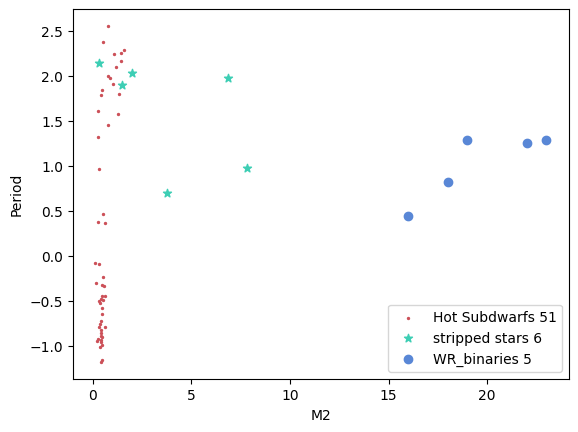

In [16]:
hot_subdwarfs = pd_catalog_data[pd_catalog_data['system_class'] == 'Hot subdwarf']
stripped_stars = pd_catalog_data[pd_catalog_data['system_class'] == 'Stripped star' ]
WR_binaries = pd_catalog_data[pd_catalog_data['system_class'] == 'WR binary' ]


# display(hot_subdwarfs)
# display(stripped_stars)
# display(WR_binaries) 


x_key = 'M2'
y_key = 'Period'

X_sdOB = to_triplet_array(hot_subdwarfs[x_key])[:,1]
Y_sdOB = np.log10(to_triplet_array(hot_subdwarfs[y_key])[:,1])
plt.scatter(X_sdOB, Y_sdOB, c = '#cc5159', s = 2,
            label = f'Hot Subdwarfs {np.sum(~np.isnan(X_sdOB)*~np.isnan(Y_sdOB))}')
            
X_stripS = to_triplet_array(stripped_stars[x_key])[:,1]
Y_stripS = np.log10(to_triplet_array(stripped_stars[y_key])[:,1])
plt.scatter(X_stripS, Y_stripS, c = '#3dceb4', marker = '*',
            label = f'stripped stars {np.sum(~np.isnan(X_stripS)*~np.isnan(Y_stripS))}')

X_WR = to_triplet_array(WR_binaries[x_key])[:,1]
Y_WR = np.log10(to_triplet_array(WR_binaries[y_key])[:,1])
plt.scatter(X_WR, Y_WR, c = '#5987d6',
            label = f'WR_binaries {np.sum(~np.isnan(X_WR) * ~np.isnan(Y_WR))}')

plt.xlabel(x_key)
plt.ylabel(y_key)
plt.legend(loc = 'lower right')
plt.savefig(PLOTS_DIR / "stripped_stars.png")
plt.show()




Unique categories in system_class:
['Blue straggler binary' 'Hot subdwarf' 'WR binary' 'Algol'
 'Chemically Peculiar' 'Astrometric compact object'
 'Spectroscopic compact object' 'Contact binary' 'Gaia compact object'
 'pulsar binary' 'post AGB' 'Stripped star' 'Spectroscopic WD + MS'
 'Astrometric WD + MS' 'high-mass XRB' 'WD + MS' 'EL CVn']


NameError: name 'valid' is not defined

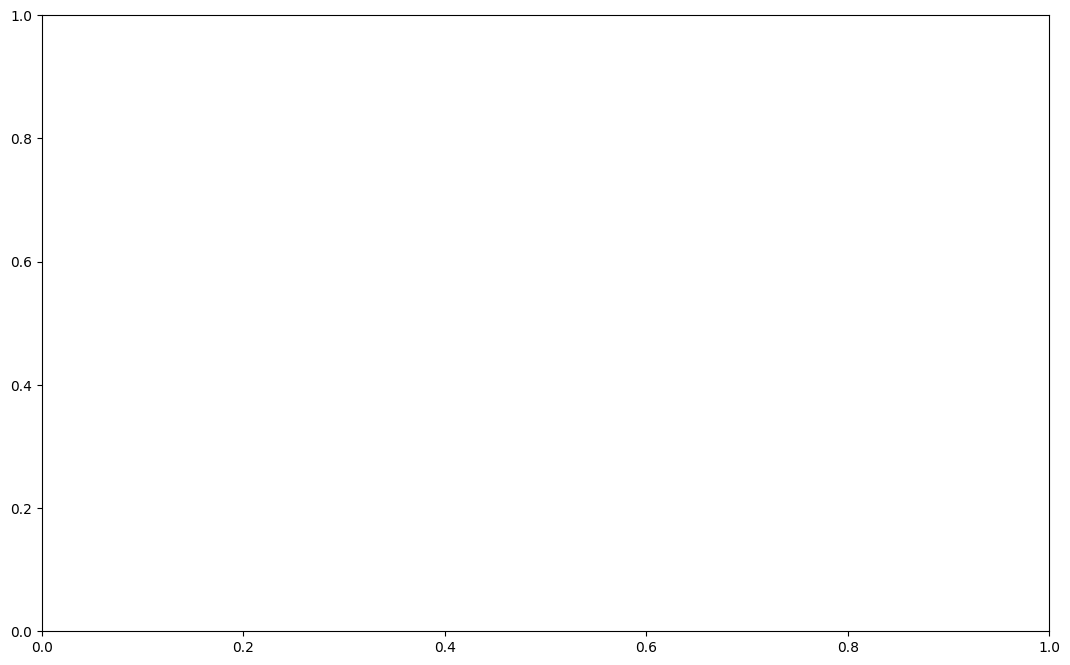

In [17]:
logx = True
logy = False

x_key = 'Period'
y_key = 'Eccentricity'
color_key = 'system_class'

table_to_plot = pd_catalog_data

# Get unique categories and create color mapping
unique_categories = table_to_plot[color_key].dropna().unique()
print(f"Unique categories in {color_key}:")
print(unique_categories)

# Define color palette - you can customize these colors
color_palette = plt.cm.tab20.colors  # Use matplotlib's tab20 colormap
color_map = {cat: color_palette[i % len(color_palette)] for i, cat in enumerate(sorted(unique_categories))}

# Map categories to colors
color_mapped = table_to_plot[color_key].map(color_map)

fig, ax = plt.subplots(figsize=(13, 8))

X_data = to_triplet_array(table_to_plot[x_key])[:,1]
Y_data = to_triplet_array(table_to_plot[y_key])[:,1]

# Plot each category separately for proper legend
for category in sorted(unique_categories):
    mask = table_to_plot[color_key] == category
    X_vals = to_triplet_array(table_to_plot.loc[mask, x_key])
    X_min, X_mid, X_max = X_vals[:,0], X_vals[:,1], X_vals[:,2]

    Y_vals = to_triplet_array(table_to_plot.loc[mask, y_key])
    Y_min, Y_mid, Y_max = Y_vals[:,0],Y_vals[:,1], Y_vals[:,2]
    
    ax.errorbar(X_mid, Y_mid, 
                xerr = (X_min, X_max),
                yerr = (Y_min, Y_max),
                c= color_map[category], 
                fmt='o',
                label=f'{category} ({np.sum(valid)})',
                alpha=0.7)

plt.xlabel(x_key, fontsize=12)
plt.ylabel(y_key, fontsize=12)
if logx:
    ax.set_xscale('log')
if logy:
    ax.set_yscale('log')

plt.legend(loc='best',bbox_to_anchor=(1.0, 1.), fontsize=10)
plt.title(f'{y_key} vs {x_key} colored by {color_key}', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{y_key}_vs_{x_key}_by_{color_key}.png", dpi=150)
plt.show()

# Print the color mapping for reference
print("\nColor mapping:")
for cat, col in color_map.items():
    print(f"  {cat}: RGB{tuple(np.round(col[:3], 3))}")


In [18]:
# Example 1: Simple usage with automatic colors
fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, color_by='system_class')
fig.show()


In [19]:
def is_number(x):
    return isinstance(x, (int, float)) and not np.isnan(x)


def extract_value_and_error(val):
    """
    Return (value, err_low, err_high)

    Rules:
    - None -> (None, None, None)
    - scalar number -> (value, None, None)
    - scalar non-number -> (value, None, None)
    - list:
        * if numeric triplet [min, max, adopted] -> compute errors
        * otherwise -> return last non-null element, no errors
    """
    if val is None:
        return None, None, None

    # Scalar
    if not isinstance(val, list):
        return val, None, None

    # List case
    # Keep non-null entries
    clean = [v for v in val if v is not None]
    if len(clean) == 0:
        return None, None, None

    # Try numeric [min, max, adopted]
    if (
        len(val) >= 3
        and is_number(val[0])
        and is_number(val[1])
        and is_number(val[2])
    ):
        vmin, vmax, vadopt = val[:3]
        err_low = vadopt - vmin if vmin is not None else None
        err_high = vmax - vadopt if vmax is not None else None
        return vadopt, err_low, err_high

    # Fallback: non-numeric list (strings, refs, methods, etc.)
    return clean[-1], None, None


In [20]:
def read_catalog(json_file):
    with open(json_file, "r") as f:
        data = json.load(f)

    rows = []
    for entry in data:
        row = {}
        for key, val in entry.items():
            value, err_low, err_high = extract_value_and_error(val)
            row[key] = value
            row[f"{key}_err_low"] = err_low
            row[f"{key}_err_high"] = err_high
        rows.append(row)

    return pd.DataFrame(rows)


df = read_catalog(MAIN_CATALOG)

In [21]:
import numpy as np
import plotly.graph_objects as go

def plot_catalog(df, x, y, color_by="system_class", logx=False, logy=False):
    """
    Interactive scatter plot of a post-mass-transfer catalog.
    
    Parameters
    ----------
    df : pd.DataFrame
        Catalog dataframe with numeric columns and *_err_low / *_err_high
    x : str
        Column name for x-axis
    y : str
        Column name for y-axis
    color_by : str
        Column name to color points by
    logx, logy : bool
        Log scale axes
    """
    # Keep only rows with finite x and y
    mask = (
        df[x].notnull() & df[y].notnull() &
        np.isfinite(df[x]) & np.isfinite(df[y])
    )
    df_plot = df[mask].copy()

    # Count totals for legend
    total_counts = df[color_by].value_counts()
    plotted_counts = df_plot[color_by].value_counts()

    fig = go.Figure()

    # Add one trace per group
    for cls, group in df_plot.groupby(color_by):
        label = f"{cls} ({plotted_counts.get(cls,0)}/{total_counts.get(cls,0)})"

        fig.add_trace(
            go.Scatter(
                x=group[x],
                y=group[y],
                mode="markers",
                name=label,
                # Initially hide error bars; toggle via buttons
                error_x=dict(
                    type="data",
                    symmetric=False,
                    array=group.get(f"{x}_err_high"),
                    arrayminus=group.get(f"{x}_err_low"),
                    visible=False,
                ),
                error_y=dict(
                    type="data",
                    symmetric=False,
                    array=group.get(f"{y}_err_high"),
                    arrayminus=group.get(f"{y}_err_low"),
                    visible=False,
                ),
                customdata=np.stack(
                    [
                        group["System Name"],
                        group["Type1"],
                        group["Type2"],
                    ],
                    axis=-1,
                ),
                hovertemplate=(
                    "<b>%{customdata[0]}</b><br>"
                    f"{x}: %{x}<br>"
                    f"{y}: %{y}<br>"
                    "Type1: %{customdata[1]}<br>"
                    "Type2: %{customdata[2]}<extra></extra>"
                ),
            )
        )

    # Add toggle buttons for errors
    n_traces = len(fig.data)
    fig.update_layout(
        template="simple_white",
        legend_title_text=color_by,
        width=900,   # width in pixels
        height=600,  # height in pixels
        xaxis_title=x,
        yaxis_title=y,
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.5,
                y=1.15,
                xanchor="center",
                buttons=[
                    dict(
                        label="Show errors",
                        method="update",
                        args=[{
                            "error_x.visible": [True]*n_traces,
                            "error_y.visible": [True]*n_traces,
                        }],
                    ),
                    dict(
                        label="Hide errors",
                        method="update",
                        args=[{
                            "error_x.visible": [False]*n_traces,
                            "error_y.visible": [False]*n_traces,
                        }],
                    ),
                ],
            )
        ]
    )

    # Log axes if requested
    if logx:
        fig.update_xaxes(type="log")
    if logy:
        fig.update_yaxes(type="log")

    fig.show()


In [22]:
plot_catalog(
    df,
    x="Period",
    y="Eccentricity",
    color_by="system_class",
    logx=True,
)


In [ ]:
pd_catalog_data[['System Name', 'Reference','Period', 'Eccentricity', 'M1', 'M2' ]][pd_catalog_data['system_class'] == 'Blue straggler binary']

IGR J18027

,System Name,Reference,Period,Eccentricity,M1,M2
0,Cl* NGC 188 PKM 451,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[4.0, 722.0, 4.0]","[0.03, 0.34, 0.03]","[None, None, None]","[None, None, None]"
1,Cl* NGC 188 PKM 1888,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[30.0, 2240.0, 30.0]","[0.04, 0.21, 0.04]","[None, None, None]","[None, None, None]"
2,Cl* NGC 188 PKM 2679,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[8.0, 1033.0, 8.0]","[0.05, 0.07, 0.05]","[None, None, None]","[None, None, None]"
3,Cl* NGC 188 PKM 4348,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[8.0, 1168.0, 8.0]","[0.05, 0.09, 0.05]","[None, None, None]","[None, None, None]"
4,Cl* NGC 188 PKM 4540,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[70.0, 3030.0, 70.0]","[0.07, 0.36, 0.07]","[None, None, None]","[None, None, None]"
5,Cl* NGC 188 PKM 4581,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[1.6, 546.7, 1.6]","[0.015, 0.269, 0.015]","[None, None, None]","[None, None, None]"
6,Cl* NGC 188 PKM 4589,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[1.7, 615.2, 1.7]","[0.04, 0.21, 0.04]","[None, None, None]","[None, None, None]"
7,Cl* NGC 188 PKM 4970,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[2.4, 1002.6, 2.4]","[0.013, 0.095, 0.013]","[None, None, None]","[None, None, None]"
8,Cl* NGC 188 PKM 5325,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[12.0, 1772.0, 12.0]","[0.03, 0.77, 0.03]","[None, None, None]","[None, None, None]"
9,Cl* NGC 188 PKM 5350,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[3.0, 690.0, 3.0]","[0.05, 0.07, 0.05]","[None, None, None]","[None, None, None]"


In [210]:
pd_catalog_data[['System Name', 'Reference' ]][pd_catalog_data['system_class'] == 'Blue straggler binary']

,System Name,Reference
0,Cl* NGC 188 PKM 451,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
1,Cl* NGC 188 PKM 1888,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
2,Cl* NGC 188 PKM 2679,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
3,Cl* NGC 188 PKM 4348,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
4,Cl* NGC 188 PKM 4540,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
5,Cl* NGC 188 PKM 4581,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
6,Cl* NGC 188 PKM 4589,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
7,Cl* NGC 188 PKM 4970,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
8,Cl* NGC 188 PKM 5325,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
9,Cl* NGC 188 PKM 5350,"[2009AJ....137.3743G, 2015ApJ...814..163G]"


In [213]:
# Count systems by class with nice formatting
print(f"Total systems in catalog: {len(pd_catalog_data)}")
print("\n" + "="*60)
print(f"{'System Class':<35} {'Count':>10}")
print("="*60)

# Get counts and sort by frequency (descending)
class_counts = [(cls, sum(pd_catalog_data['system_class'] == cls)) 
                for cls in np.unique(pd_catalog_data['system_class'])]
class_counts.sort(key=lambda x: x[1], reverse=True)

for sys_class, count in class_counts:
    print(f"{sys_class:<35} {count:>10,}")

print("="*60)
print(f"{'TOTAL':<35} {len(pd_catalog_data):>10,}")
print("="*60)

Total systems in catalog: 4613

System Class                             Count
WD + MS                                  3,909
high-mass XRB                              162
Algol                                      126
Hot subdwarf                               123
Chemically Peculiar                         82
EL CVn                                      65
post AGB                                    33
Gaia compact object                         24
Contact binary                              22
WR binary                                   19
Blue straggler binary                       17
Spectroscopic binary with dormant CO         14
Stripped star                                9
pulsar binary                                8
TOTAL                                    4,613


In [212]:
# Filter out NaN values before checking unique source files
source_files = pd_catalog_data['source_file'].dropna()
print("Unique source files:")
# print(np.unique(source_files))

# Check if any systems have 'WDMS/' in their source_file
WD_MS_sys_bool = pd_catalog_data['source_file'].str.contains('WDMS/', na=False)
print(f"\nNumber of WDMS systems: {WD_MS_sys_bool.sum()}")

display(np.unique(pd_catalog_data['source_file'][WD_MS_sys_bool]))

Unique source files:

Number of WDMS systems: 3499


array(['WDMS/Escorza2019.h5', 'WDMS/RebassaMansergas2012.h5',
       'WDMS/Shahaf2024.h5', 'WDMS/WD_Binary_Pathways_VI.h5',
       'WDMS/WD_Binary_Pathways_X.h5', 'WDMS/Zorotovic2010.h5'],
      dtype=object)

In [176]:
# WDMS/RebassaMansergas2012.h5',
# WDMS/Shahaf2024.h5', 
# WDMS/Zorotovic2010.h5
# 'WDMS/WD_Binary_Pathways_VI.h5',
# 'WDMS/WD_Binary_Pathways_X.h5', 

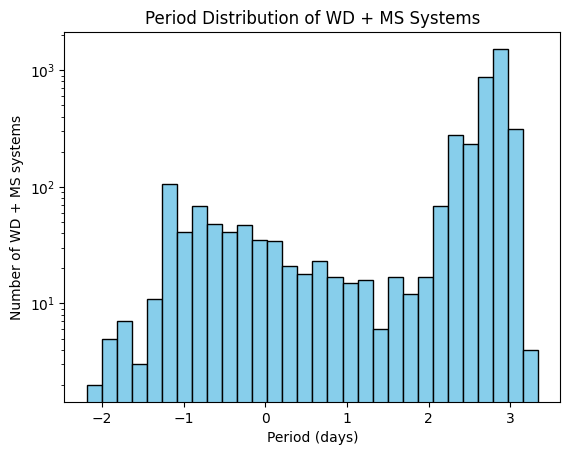

In [177]:
WD_MS_sys_class = pd_catalog_data['system_class'] == 'WD + MS'

logP = np.log10(to_triplet_array(pd_catalog_data['Period'][WD_MS_sys_class])[:,1])
plt.hist(logP, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Period (days)')
plt.ylabel('Number of WD + MS systems')
plt.title('Period Distribution of WD + MS Systems')
plt.yscale('log')
plt.savefig(PLOTS_DIR / "WD_MS_period_distribution.png", dpi=150  )
plt.show()



In [178]:
np.unique(pd_catalog_data['evol_type_2'].dropna())

array(['AGB', 'BH', 'HG', 'He-star', 'MS', 'NS', 'RGB', 'WD'],
      dtype=object)

In [187]:
table_bool = np.logical_and(pd_catalog_data['system_class'] == "high-mass XRB", pd_catalog_data['obs_type_2'] == "BH" )
M2 = to_triplet_array(pd_catalog_data['M2'] )
table_bool = np.logical_and(pd_catalog_data['system_class'] == "high-mass XRB", M2[:,1] > 2 )
(pd_catalog_data[['Reference', 'System Name', 'system_class', 'M1', 'M2', 'evol_type_1', 'evol_type_2', 'obs_type_1', 'obs_type_2', 'source_file','system_class']][table_bool])



,Reference,System Name,system_class,M1,M2,evol_type_1,evol_type_2,obs_type_1,obs_type_2,source_file,system_class
3895,"[1978mcts.book.....H, 2015A&A...577A.130F, 199...",Vela X-1,high-mass XRB,"[1.0, 26.0, 1.0]","[0.16, 2.12, 0.16]",MS,NS,B0.5Iae-1b,NS,NaN,high-mass XRB
3901,"[1993ApJS...87..197G, 2021ApJ...913...48G]",HD 96670,high-mass XRB,"[5.2, 22.7, 5.2]","[0.9, 6.2, 0.9]",MS,BH,O7V(f)n,BH,NaN,high-mass XRB
3957,"[2020MNRAS.493.2694S, 2017ApJ...843L..10S]",1E 1740.7-2942,high-mass XRB,"[None, None, None]","[1.1, 5.0, 1.1]",MS,BH,None,BH,NaN,high-mass XRB
3971,"[2001ApJ...555..489O, 2005MNRAS.363..882L]",SAX J1819.3-2525,high-mass XRB,"[1.4, 6.8, 1.4]","[1.5, 10.2, 1.5]",MS,BH,B9III,BH,NaN,high-mass XRB
4002,"[2004ApJ...615..422H, 2020A&A...640A..96P, 200...",SS 433,high-mass XRB,"[0.6, 11.3, 0.6]","[0.4, 4.2, 0.4]",MS,BH,A7Ib,BH,NaN,high-mass XRB
4011,"[2011ApJS..193...24S, 2021Sci...371.1046M, 199...",Cyg X-1,high-mass XRB,"[7.7, 40.6, 7.7]","[2.2, 21.2, 2.2]",MS,None,O9.7Iabpvar,None,NaN,high-mass XRB
4017,"[1996A&A...314..521V, 2022ApJ...926..123A, 201...",Cyg X-3,high-mass XRB,"[None, None, None]","[None, 7.2, None]",MS,None,WN4/5-6/7,None,NaN,high-mass XRB
4025,"[2014Natur.505..378C, 2010ApJ...723L..93W, 201...",MWC 656,high-mass XRB,"[2.0, 7.8, 2.0]","[1.6, 5.4, 1.6]",MS,BH,B1.5-B2IIIe,BH,NaN,high-mass XRB


In [184]:
(pd_catalog_data[['System Name','Reference']][table_bool])


,System Name,Reference
3901,HD 96670,"[1993ApJS...87..197G, 2021ApJ...913...48G]"
3957,1E 1740.7-2942,"[2020MNRAS.493.2694S, 2017ApJ...843L..10S]"
3971,SAX J1819.3-2525,"[2001ApJ...555..489O, 2005MNRAS.363..882L]"
4002,SS 433,"[2004ApJ...615..422H, 2020A&A...640A..96P, 200..."
4025,MWC 656,"[2014Natur.505..378C, 2010ApJ...723L..93W, 201..."


In [181]:
pulsar_bool = ["Pulsar" in note for note in pd_catalog_data['Notes'].dropna() ] 
print(sum(pulsar_bool))
# display(pd_catalog_data[pulsar_bool] )

8
